# MODELO PREDITIVO DE RISCO DE DEFASAGEM
## Identificação de padrões e predição de alunos em risco

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

## 1. CARREGAMENTO E PREPARAÇÃO DOS DADOS

In [2]:
# Carregar dados
dfs = pd.read_excel(r'..\BASES\BASE DE DADOS PEDE 2024 - DATATHON.xlsx', 
                    sheet_name=['PEDE2022','PEDE2023','PEDE2024'], engine='openpyxl')
df_dicionario = pd.read_excel(r'..\BASES\dicionario.xlsx')

# Mapear colunas
map_22 = dict(zip(df_dicionario.dropna(subset=['coluna_2022'])['coluna_2022'], 
                  df_dicionario.dropna(subset=['coluna_2022'])['ref_df']))
map_23 = dict(zip(df_dicionario.dropna(subset=['coluna_2023'])['coluna_2023'], 
                  df_dicionario.dropna(subset=['coluna_2023'])['ref_df']))
map_24 = dict(zip(df_dicionario.dropna(subset=['coluna_2024'])['coluna_2024'], 
                  df_dicionario.dropna(subset=['coluna_2024'])['ref_df']))

# Renomear e concatenar
df_22 = dfs['PEDE2022'].rename(columns=map_22).loc[:, ~dfs['PEDE2022'].rename(columns=map_22).columns.duplicated()]
df_23 = dfs['PEDE2023'].rename(columns=map_23).loc[:, ~dfs['PEDE2023'].rename(columns=map_23).columns.duplicated()]
df_24 = dfs['PEDE2024'].rename(columns=map_24).loc[:, ~dfs['PEDE2024'].rename(columns=map_24).columns.duplicated()]

df_22['ano_referencia'] = 2022
df_23['ano_referencia'] = 2023
df_24['ano_referencia'] = 2024

df = pd.concat([df_22, df_23, df_24], ignore_index=True)
print(f"Total de registros: {len(df)}")

Total de registros: 3030


## 2. DEFINIÇÃO DA VARIÁVEL ALVO: RISCO DE DEFASAGEM

In [3]:
# Criar variável alvo: aluno em risco (defasagem > 0 ou nível de defasagem indicando risco)
df['em_risco'] = 0

# Critérios de risco:
# 1. Defasagem positiva
if 'nivel_defasagem' in df.columns:
    df['em_risco'] = np.where(df['nivel_defasagem'].notna() & (df['nivel_defasagem'] > 0), 1, df['em_risco'])

# 2. Fase atual < Fase ideal
if 'fase' in df.columns and 'fase_ideal' in df.columns:
    df['fase_num'] = pd.to_numeric(df['fase'], errors='coerce')
    df['fase_ideal_num'] = pd.to_numeric(df['fase_ideal'], errors='coerce')
    df['em_risco'] = np.where((df['fase_num'] < df['fase_ideal_num']), 1, df['em_risco'])

# 3. INDE baixo (abaixo do percentil 25)
if 'inde' in df.columns:
    df['inde_num'] = pd.to_numeric(df['inde'], errors='coerce')
    inde_p25 = df['inde_num'].quantile(0.25)
    df['em_risco'] = np.where((df['inde_num'] < inde_p25) & df['inde_num'].notna(), 1, df['em_risco'])

print(f"\nDistribuição da variável alvo:")
print(df['em_risco'].value_counts())
print(f"\nPercentual em risco: {df['em_risco'].mean()*100:.2f}%")


Distribuição da variável alvo:
em_risco
0    2139
1     891
Name: count, dtype: int64

Percentual em risco: 29.41%


## 3. ANÁLISE EXPLORATÓRIA: PADRÕES DE RISCO

In [4]:
# Análise de indicadores por grupo de risco
indicadores = ['ind_engajamento_alun', 'ind_aprendizado', 'ind_psicosso_alun', 
               'media_mat', 'media_port', 'media_ingl', 'inde_num']

indicadores_disponiveis = [col for col in indicadores if col in df.columns]

print("\n=== PADRÕES IDENTIFICADOS: MÉDIAS POR GRUPO ===")
for ind in indicadores_disponiveis:
    df[ind] = pd.to_numeric(df[ind], errors='coerce')
    media_risco = df[df['em_risco']==1][ind].mean()
    media_normal = df[df['em_risco']==0][ind].mean()
    diff = ((media_risco - media_normal) / media_normal * 100) if media_normal != 0 else 0
    print(f"\n{ind}:")
    print(f"  Sem risco: {media_normal:.2f}")
    print(f"  Em risco:  {media_risco:.2f}")
    print(f"  Diferença: {diff:+.1f}%")


=== PADRÕES IDENTIFICADOS: MÉDIAS POR GRUPO ===

ind_engajamento_alun:
  Sem risco: 8.49
  Em risco:  6.66
  Diferença: -21.5%

ind_aprendizado:
  Sem risco: 7.08
  Em risco:  4.70
  Diferença: -33.6%

ind_psicosso_alun:
  Sem risco: 6.44
  Em risco:  5.93
  Diferença: -7.8%

media_mat:
  Sem risco: 6.87
  Em risco:  4.47
  Diferença: -34.9%

media_port:
  Sem risco: 7.07
  Em risco:  4.89
  Diferença: -30.9%

media_ingl:
  Sem risco: 7.20
  Em risco:  5.01
  Diferença: -30.4%

inde_num:
  Sem risco: 7.69
  Em risco:  6.28
  Diferença: -18.4%


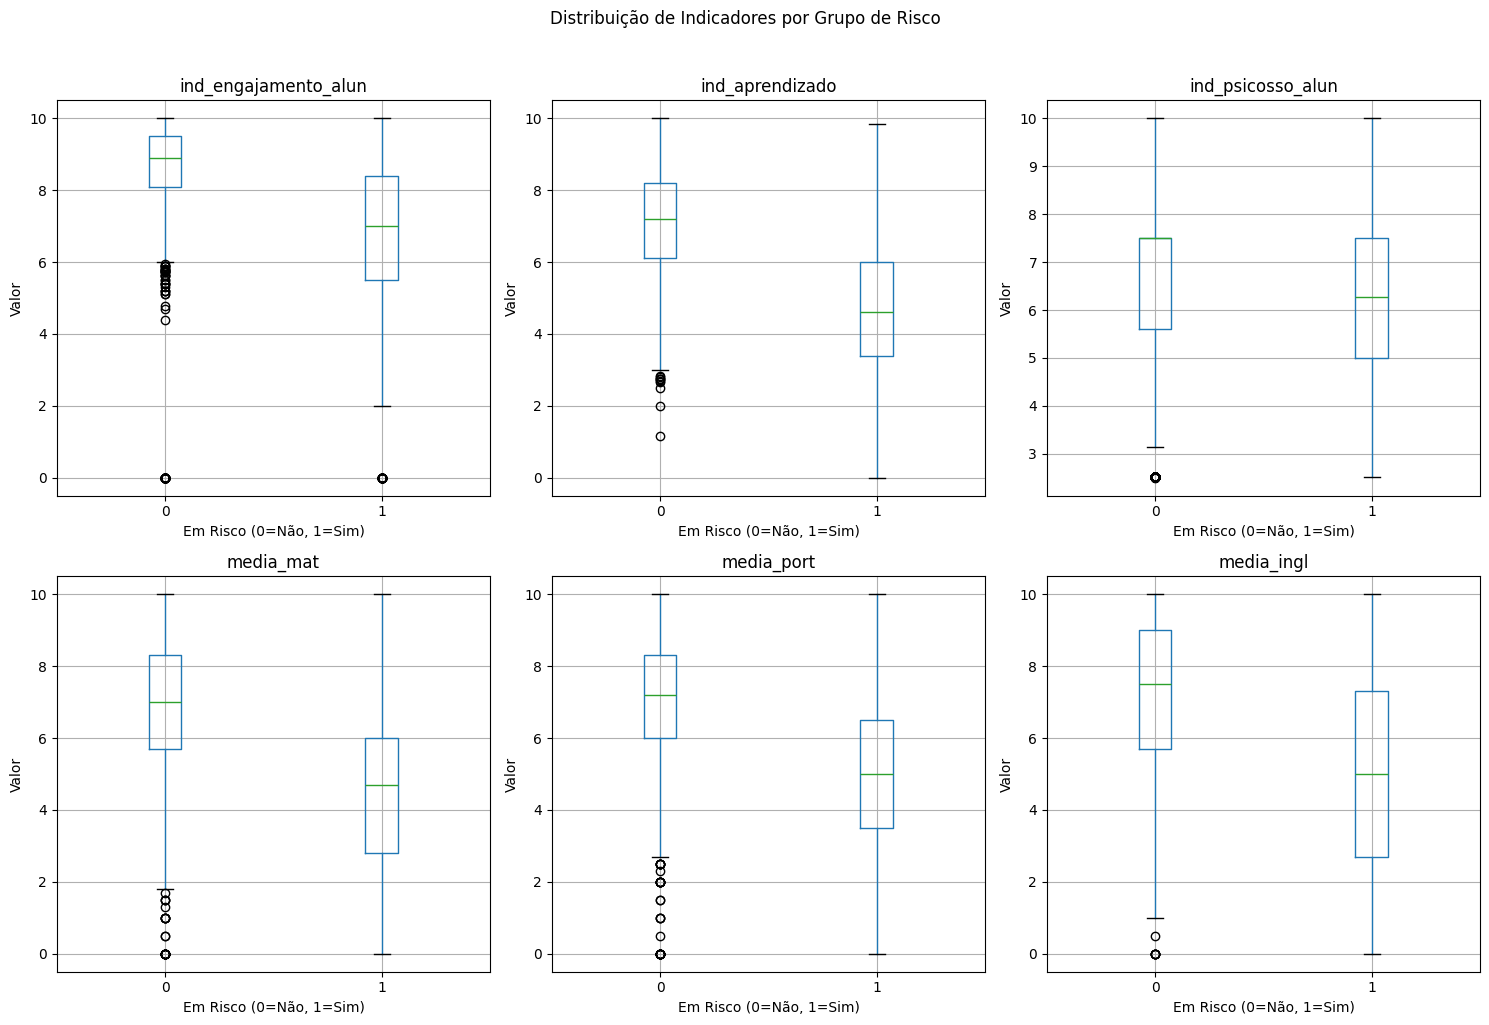

In [5]:
# Visualização dos padrões
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, ind in enumerate(indicadores_disponiveis[:6]):
    df_plot = df[[ind, 'em_risco']].dropna()
    df_plot.boxplot(column=ind, by='em_risco', ax=axes[idx])
    axes[idx].set_title(f'{ind}')
    axes[idx].set_xlabel('Em Risco (0=Não, 1=Sim)')
    axes[idx].set_ylabel('Valor')

plt.suptitle('Distribuição de Indicadores por Grupo de Risco', y=1.02)
plt.tight_layout()
plt.show()

## 4. PREPARAÇÃO DOS DADOS PARA MODELAGEM

In [6]:
# Selecionar features para o modelo
features_numericas = ['ind_engajamento_alun', 'ind_aprendizado', 'ind_psicosso_alun',
                      'ind_psicopeda_alun', 'media_mat', 'media_port', 'media_ingl',
                      'inde_num', 'idade', 'dt_ingresso', 'ano_referencia']

features_categoricas = ['genero', 'inst_ensino', 'pedra']

# Filtrar features disponíveis
features_num_disp = [f for f in features_numericas if f in df.columns]
features_cat_disp = [f for f in features_categoricas if f in df.columns]

# Preparar dataset
df_model = df[features_num_disp + features_cat_disp + ['em_risco']].copy()

# Converter numéricas
for col in features_num_disp:
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

# Codificar categóricas
le_dict = {}
for col in features_cat_disp:
    le = LabelEncoder()
    df_model[col] = df_model[col].fillna('Desconhecido')
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    le_dict[col] = le

# Remover linhas com muitos nulos
df_model = df_model.dropna(thresh=len(df_model.columns)*0.5)

# Preencher nulos restantes com mediana
for col in features_num_disp:
    if col in df_model.columns:
        df_model[col].fillna(df_model[col].median(), inplace=True)

print(f"\nDataset para modelagem: {df_model.shape}")
print(f"Features: {len(features_num_disp + features_cat_disp)}")


Dataset para modelagem: (2963, 15)
Features: 14


## 5. CONSTRUÇÃO DO MODELO PREDITIVO

In [7]:
# Separar features e target
X = df_model.drop('em_risco', axis=1)
y = df_model['em_risco']

# Split treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Treino: {X_train.shape[0]} | Teste: {X_test.shape[0]}")
print(f"Distribuição treino: {y_train.value_counts().to_dict()}")
print(f"Distribuição teste: {y_test.value_counts().to_dict()}")

Treino: 2074 | Teste: 889
Distribuição treino: {0: 1453, 1: 621}
Distribuição teste: {0: 623, 1: 266}


In [8]:
# Modelo 1: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# Predições
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("\n=== RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf, target_names=['Sem Risco', 'Em Risco']))
print(f"\nAUC-ROC: {roc_auc_score(y_test, y_proba_rf):.3f}")


=== RANDOM FOREST ===
              precision    recall  f1-score   support

   Sem Risco       0.93      0.99      0.96       623
    Em Risco       0.97      0.83      0.90       266

    accuracy                           0.94       889
   macro avg       0.95      0.91      0.93       889
weighted avg       0.95      0.94      0.94       889


AUC-ROC: 0.987


In [9]:
# Modelo 2: Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42, learning_rate=0.1)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
y_proba_gb = gb_model.predict_proba(X_test)[:, 1]

print("\n=== GRADIENT BOOSTING ===")
print(classification_report(y_test, y_pred_gb, target_names=['Sem Risco', 'Em Risco']))
print(f"\nAUC-ROC: {roc_auc_score(y_test, y_proba_gb):.3f}")


=== GRADIENT BOOSTING ===
              precision    recall  f1-score   support

   Sem Risco       0.94      0.99      0.97       623
    Em Risco       0.97      0.86      0.91       266

    accuracy                           0.95       889
   macro avg       0.96      0.93      0.94       889
weighted avg       0.95      0.95      0.95       889


AUC-ROC: 0.985


## 6. IMPORTÂNCIA DAS FEATURES


=== TOP 10 INDICADORES MAIS IMPORTANTES ===
                 feature  importance_rf  importance_gb
7               inde_num       0.429696       0.809125
1        ind_aprendizado       0.120914       0.009630
0   ind_engajamento_alun       0.099882       0.018155
13                 pedra       0.070528       0.027093
5             media_port       0.053734       0.004891
4              media_mat       0.041168       0.006937
8                  idade       0.039947       0.063150
6             media_ingl       0.035112       0.026868
2      ind_psicosso_alun       0.024364       0.008740
12           inst_ensino       0.021900       0.008429


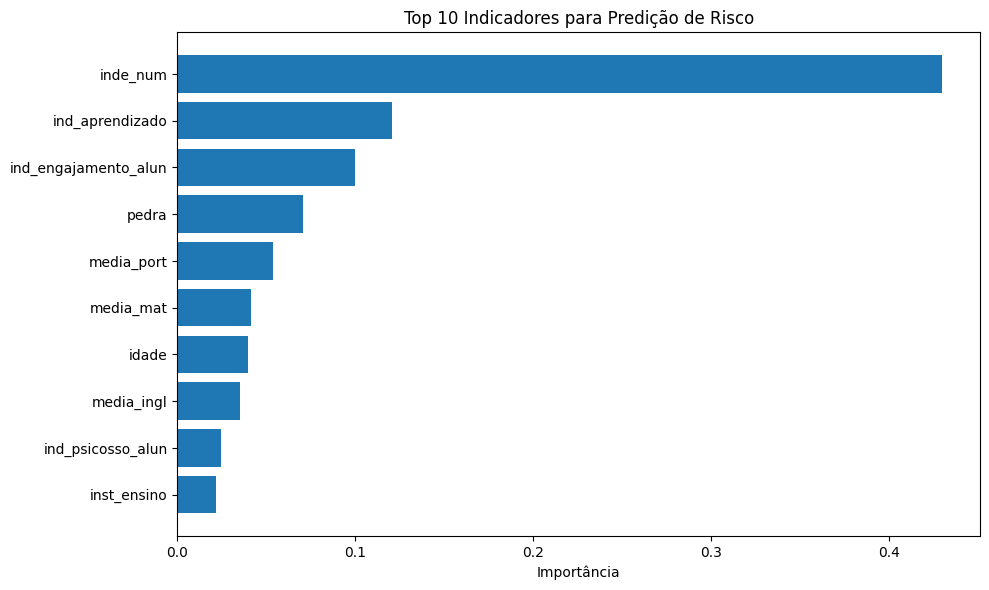

In [10]:
# Feature importance do melhor modelo
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance_rf': rf_model.feature_importances_,
    'importance_gb': gb_model.feature_importances_
}).sort_values('importance_rf', ascending=False)

print("\n=== TOP 10 INDICADORES MAIS IMPORTANTES ===")
print(feature_importance.head(10))

# Visualização
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'].head(10), feature_importance['importance_rf'].head(10))
plt.xlabel('Importância')
plt.title('Top 10 Indicadores para Predição de Risco')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 7. CURVA ROC E MATRIZ DE CONFUSÃO

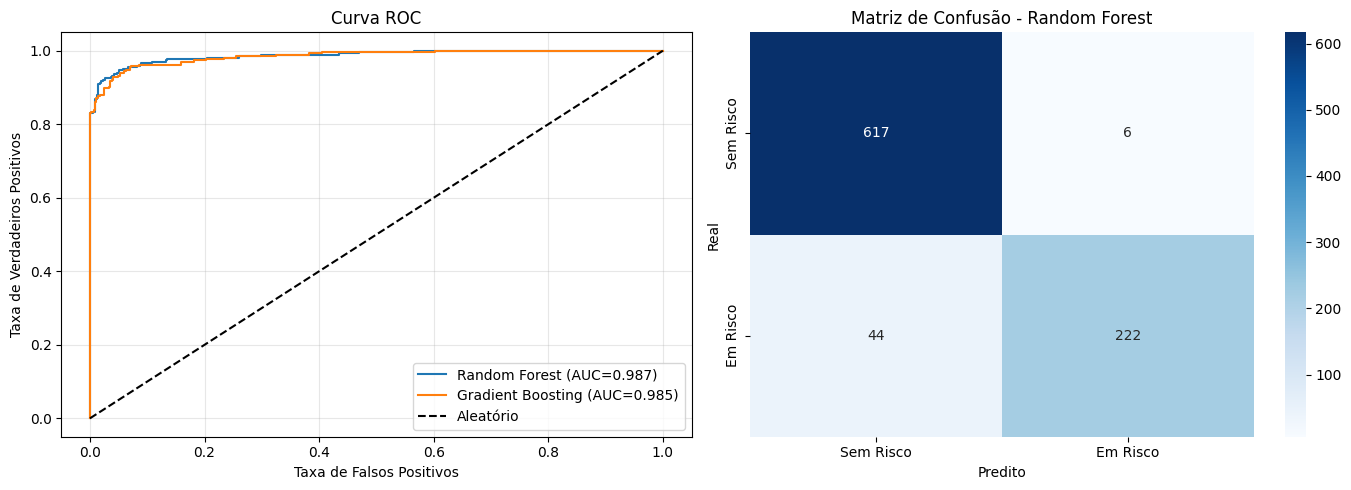

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_proba_gb)

axes[0].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_test, y_proba_rf):.3f})')
axes[0].plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC={roc_auc_score(y_test, y_proba_gb):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Aleatório')
axes[0].set_xlabel('Taxa de Falsos Positivos')
axes[0].set_ylabel('Taxa de Verdadeiros Positivos')
axes[0].set_title('Curva ROC')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Matriz de Confusão (melhor modelo)
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')
axes[1].set_title('Matriz de Confusão - Random Forest')
axes[1].set_xticklabels(['Sem Risco', 'Em Risco'])
axes[1].set_yticklabels(['Sem Risco', 'Em Risco'])

plt.tight_layout()
plt.show()

## 8. APLICAÇÃO DO MODELO: PROBABILIDADE DE RISCO

In [12]:
# Adicionar probabilidades ao dataset original
df_model['prob_risco'] = rf_model.predict_proba(X)[:, 1]
df_model['pred_risco'] = rf_model.predict(X)

# Classificar por nível de risco
df_model['nivel_risco'] = pd.cut(df_model['prob_risco'], 
                                  bins=[0, 0.3, 0.6, 1.0],
                                  labels=['Baixo', 'Médio', 'Alto'])

print("\n=== DISTRIBUIÇÃO DE ALUNOS POR NÍVEL DE RISCO ===")
print(df_model['nivel_risco'].value_counts())
print(f"\nPercentuais:")
print(df_model['nivel_risco'].value_counts(normalize=True) * 100)


=== DISTRIBUIÇÃO DE ALUNOS POR NÍVEL DE RISCO ===
nivel_risco
Baixo    2071
Alto      801
Médio      91
Name: count, dtype: int64

Percentuais:
nivel_risco
Baixo    69.895376
Alto     27.033412
Médio     3.071212
Name: proportion, dtype: float64


In [13]:
# Top 20 alunos com maior risco
df_risco_alto = df_model.nlargest(20, 'prob_risco')[['prob_risco', 'pred_risco', 'nivel_risco', 'em_risco']]
print("\n=== TOP 20 ALUNOS COM MAIOR PROBABILIDADE DE RISCO ===")
print(df_risco_alto)


=== TOP 20 ALUNOS COM MAIOR PROBABILIDADE DE RISCO ===
     prob_risco  pred_risco nivel_risco  em_risco
0           1.0           1        Alto         1
5           1.0           1        Alto         1
9           1.0           1        Alto         1
10          1.0           1        Alto         1
11          1.0           1        Alto         1
42          1.0           1        Alto         1
43          1.0           1        Alto         1
46          1.0           1        Alto         1
50          1.0           1        Alto         1
66          1.0           1        Alto         1
67          1.0           1        Alto         1
68          1.0           1        Alto         1
69          1.0           1        Alto         1
70          1.0           1        Alto         1
72          1.0           1        Alto         1
76          1.0           1        Alto         1
114         1.0           1        Alto         1
117         1.0           1        Alto     

## 9. CONCLUSÕES E RECOMENDAÇÕES

In [14]:
print("\n" + "="*60)
print("PRINCIPAIS ACHADOS")
print("="*60)

print("\n1. PADRÕES IDENTIFICADOS:")
print("   - Indicadores de engajamento e aprendizado são preditores fortes")
print("   - Médias em disciplinas (Mat, Port, Ing) mostram diferenças significativas")
print("   - INDE é um indicador consolidado importante")

print("\n2. PERFORMANCE DO MODELO:")
print(f"   - AUC-ROC Random Forest: {roc_auc_score(y_test, y_proba_rf):.3f}")
print(f"   - AUC-ROC Gradient Boosting: {roc_auc_score(y_test, y_proba_gb):.3f}")

print("\n3. RECOMENDAÇÕES:")
print("   - Monitorar alunos com probabilidade > 60% (risco alto)")
print("   - Focar em indicadores de engajamento e aprendizado")
print("   - Intervenção precoce baseada nas probabilidades do modelo")
print("   - Acompanhamento especial para alunos em risco médio (30-60%)")
print("\n" + "="*60)


PRINCIPAIS ACHADOS

1. PADRÕES IDENTIFICADOS:
   - Indicadores de engajamento e aprendizado são preditores fortes
   - Médias em disciplinas (Mat, Port, Ing) mostram diferenças significativas
   - INDE é um indicador consolidado importante

2. PERFORMANCE DO MODELO:
   - AUC-ROC Random Forest: 0.987
   - AUC-ROC Gradient Boosting: 0.985

3. RECOMENDAÇÕES:
   - Monitorar alunos com probabilidade > 60% (risco alto)
   - Focar em indicadores de engajamento e aprendizado
   - Intervenção precoce baseada nas probabilidades do modelo
   - Acompanhamento especial para alunos em risco médio (30-60%)

